# Customer Analysis

This notebook analyzes customer purchasing behavior, customer value, and repeat purchases.

## Customer Value

Customer value is evaluated based on total spending and order frequency.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv"
)

customers = pd.read_csv(
    DATA_DIR / "olist_customers_dataset.csv"
)

order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

In [2]:
orders.shape
customers.shape
order_items.shape

(112650, 7)

In [3]:
customers[["customer_id", "customer_unique_id"]].head()

,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


In [4]:
customers["customer_unique_id"].nunique()

96096

In [5]:
customer_orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [6]:
customer_orders["customer_unique_id"].isna().sum()

np.int64(0)

In [7]:
customer_orders["order_id"].nunique(), customer_orders["customer_unique_id"].nunique()

(99441, 96096)

In [8]:
customer_order_items = customer_orders[
    ["order_id", "customer_unique_id"]
].merge(
    order_items[["order_id", "price"]],
    on="order_id",
    how="left",
    validate="one_to_many"
)

In [9]:
customer_value = (
    customer_order_items
    .groupby("customer_unique_id")
    .agg(
        total_spend=("price", "sum"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

In [10]:
customer_value.sort_values(
    "total_spend",
    ascending=False
).head(10)

,customer_unique_id,total_spend,order_count
3826,0a0a92112bd4c708ca5fde585afaa872,13440.0,1
81962,da122df9eeddfedc1dc1f5349a1a690c,7388.0,2
44447,763c8b1c9c68a0229c42c9fc6f662b93,7160.0,1
82808,dc4802a71eae9be1dd28f5d788ceb526,6735.0,1
26205,459bef486812aa25204be022145caa62,6729.0,1
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0,1
24121,4007669dec559734d6f53e029e360987,5934.6,1
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0,1
35070,5d0a2980b292d049061542014e8960bf,4599.9,1
27441,48e1ac109decbb87765a3eade6854098,4590.0,1


In [11]:
customer_value["order_count"].value_counts().sort_index()

order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [12]:
customer_value["total_spend"].describe()

count    96096.000000
mean       141.438184
std        217.215904
min          0.000000
25%         45.990000
50%         89.000000
75%        154.000000
max      13440.000000
Name: total_spend, dtype: float64

In [13]:
repeat_customers = (
    customer_value["order_count"] > 1
).sum()

total_customers = customer_value["customer_unique_id"].nunique()

repeat_customer_rate = repeat_customers / total_customers

repeat_customers, total_customers, repeat_customer_rate

(np.int64(2997), 96096, np.float64(0.031187562437562436))

In [14]:
customer_value["customer_type"] = (
    customer_value["order_count"]
    .gt(1)
    .map({True: "Repeat", False: "One-time"})
)

In [15]:
customer_type_summary = (
    customer_value
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_spend=("total_spend", "mean"),
        median_spend=("total_spend", "median"),
        total_spend=("total_spend", "sum")
    )
    .reset_index()
)

customer_type_summary

,customer_type,customers,avg_spend,median_spend,total_spend
0,One-time,93099,137.625772,85.90,12812821.73
1,Repeat,2997,259.867191,179.89,778821.97


In [16]:
customer_value = customer_value.sort_values(
    "total_spend",
    ascending=False
).reset_index(drop=True)

customer_value["cumulative_spend_share"] = (
    customer_value["total_spend"].cumsum()
    / customer_value["total_spend"].sum()
)

In [17]:
customer_value.head(100)["total_spend"].sum() / customer_value["total_spend"].sum()

np.float64(0.02451093314048543)

In [18]:
customer_value.head(1000)["total_spend"].sum() / customer_value["total_spend"].sum()

np.float64(0.11859508574375002)

## Repeat Purchase Rate

Repeat Purchase Rate is defined as the percentage of unique customers who placed more than one order.

In [19]:
repeat_purchase_rate = (
    customer_value["order_count"].gt(1).mean()
)

repeat_purchase_rate

np.float64(0.031187562437562436)

In [21]:
import matplotlib.pyplot as plt

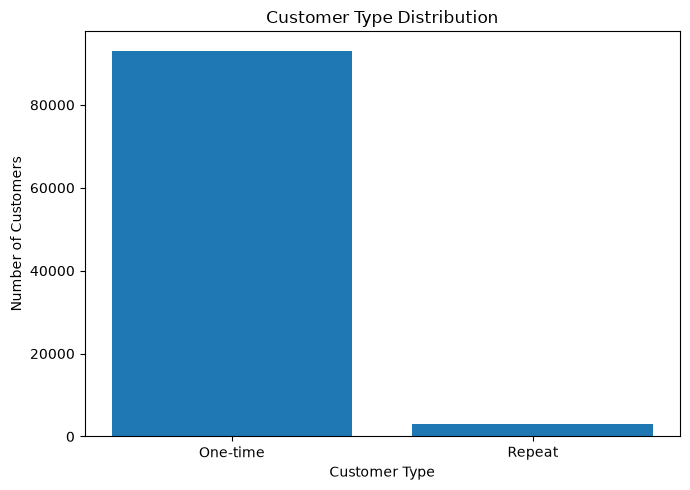

In [22]:
customer_counts = (
    customer_value["customer_type"]
    .value_counts()
    .reindex(["One-time", "Repeat"])
)

plt.figure(figsize=(7, 5))

plt.bar(
    customer_counts.index,
    customer_counts.values
)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

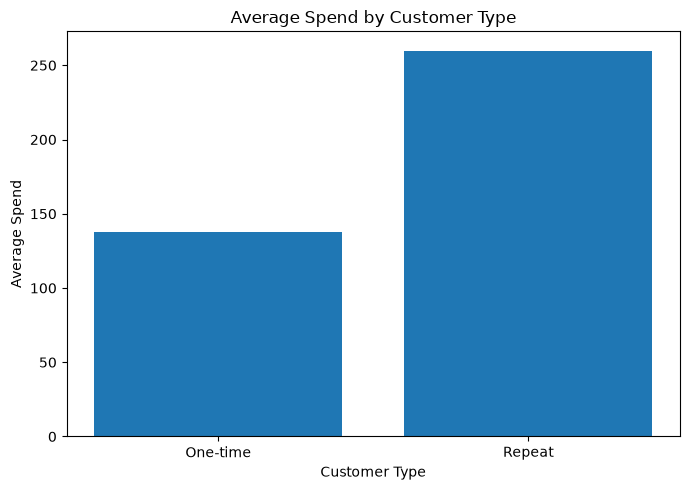

In [23]:
avg_spend = (
    customer_type_summary
    .set_index("customer_type")
    .loc[["One-time", "Repeat"], "avg_spend"]
)

plt.figure(figsize=(7, 5))

plt.bar(
    avg_spend.index,
    avg_spend.values
)

plt.title("Average Spend by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Spend")
plt.tight_layout()
plt.show()

## Key Findings

Repeat customers represent only 3.12% of the customer base, but their average spend is substantially higher than that of one-time customers (259.87 vs. 137.63).

This suggests that repeat customers are more valuable on a per-customer basis, although they currently represent a small share of the customer base.